In [4]:
# Loading the game recommendations dataset from kaggle as per the system architecture.
#!/bin/bash
!curl -L -o ~/projects/game_recommender_system/v0/data/raw/game-recommendations-on-steam.zip\
  https://www.kaggle.com/api/v1/datasets/download/antonkozyriev/game-recommendations-on-steam

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  660M  100  660M    0     0  28.1M      0  0:00:23  0:00:23 --:--:-- 29.9M


In [23]:
# Extracting the data
!unzip /home/ritishu/projects/game_recommender_system/v0/data/raw/game-recommendations-on-steam.zip

Archive:  /home/ritishu/projects/game_recommender_system/v0/data/raw/game-recommendations-on-steam.zip
  inflating: games.csv               
  inflating: games_metadata.json     
  inflating: recommendations.csv     
  inflating: users.csv               


In [27]:
# Moving the extracted data to the same folder as of *.zip file.
!mv ~/projects/game_recommender_system/games_metadata.json v0/data/raw/
!mv ~/projects/game_recommender_system/games.csv v0/data/raw/
!mv ~/projects/game_recommender_system/recommendations.csv v0/data/raw/
!mv ~/projects/game_recommender_system/users.csv v0/data/raw/

In [1]:
# Loading the data files and processing them, one-by-one.
import pandas as pd
games = pd.read_csv("~/projects/game_recommender_system/v0/data/raw/games.csv")

In [2]:
games

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,True,False,False,Very Positive,96,101,22.00,0.00,0.0,True
50868,1272080,PAYDAY 3,2023-09-21,True,False,False,Mostly Negative,38,29458,40.00,0.00,0.0,True
50869,1402110,Eternights,2023-09-11,True,False,False,Very Positive,89,1128,30.00,0.00,0.0,True
50870,2272250,Forgive Me Father 2,2023-10-19,True,False,False,Very Positive,95,82,17.00,0.00,0.0,True


In [ ]:
# Check for NULL/NaN/missing values and data types of features for future reference.
games.info()
print(games.isna().value_counts())
games.isnull().value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   app_id          50872 non-null  int64  
 1   title           50872 non-null  object 
 2   date_release    50872 non-null  object 
 3   win             50872 non-null  bool   
 4   mac             50872 non-null  bool   
 5   linux           50872 non-null  bool   
 6   rating          50872 non-null  object 
 7   positive_ratio  50872 non-null  int64  
 8   user_reviews    50872 non-null  int64  
 9   price_final     50872 non-null  float64
 10  price_original  50872 non-null  float64
 11  discount        50872 non-null  float64
 12  steam_deck      50872 non-null  bool   
dtypes: bool(4), float64(3), int64(3), object(3)
memory usage: 3.7+ MB
app_id  title  date_release  win    mac    linux  rating  positive_ratio  user_reviews  price_final  price_original  discount  steam_deck
False  

app_id  title  date_release  win    mac    linux  rating  positive_ratio  user_reviews  price_final  price_original  discount  steam_deck
False   False  False         False  False  False  False   False           False         False        False           False     False         50872
Name: count, dtype: int64

In [4]:
# Check for duplicate values.
print(games.duplicated(keep=False).value_counts())
# specifically, in app_id and title columns
print(games.duplicated("app_id", keep=False).value_counts())
print(games.duplicated("title", keep=False).value_counts())

False    50872
Name: count, dtype: int64
False    50872
Name: count, dtype: int64
False    50639
True       233
Name: count, dtype: int64


In [5]:
# because duplicacy in title column is seen, lets see how does that actually look to make any further decision. Without keeping any of the duplicates.
games[games.duplicated("title", keep='first') == True]['title'].value_counts()

title
Loop                 3
Beyond the Wall      2
Outpost              2
Flashback            2
Cursed               2
                    ..
Bottle               1
Ritual               1
Shutter              1
The Visitor          1
Blade of Darkness    1
Name: count, Length: 112, dtype: int64

In [6]:
games[games.duplicated("title", keep=False) == True]

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
683,2233890,Prison Wars,2023-01-06,True,False,False,Positive,92,14,1.99,1.99,0.0,True
966,1452500,The Good Life,2021-10-15,True,False,False,Very Positive,80,120,29.99,29.99,0.0,True
2336,844040,RUSH,2018-07-13,True,False,False,Very Positive,82,186,19.99,19.99,0.0,True
2661,1526180,Hide and Seek,2021-11-12,True,False,False,Mostly Positive,78,76,2.99,2.99,0.0,True
2810,574180,Remnants,2021-03-05,True,False,False,Mostly Positive,75,627,15.99,15.99,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50098,2340010,Ritual,2023-05-02,True,False,False,Mostly Negative,35,14,4.99,4.99,0.0,True
50119,2314110,Shutter,2023-04-28,True,False,False,Positive,91,46,0.00,0.00,0.0,True
50500,2365200,Loop,2023-06-25,True,True,True,Positive,100,12,0.00,0.00,0.0,True
50585,2239320,The Visitor,2022-12-22,True,False,False,Mixed,40,10,0.00,0.00,0.0,True


In [7]:
games[games['title'] == 'Loop'], games[games['title'] == 'Ritual']

(        app_id title date_release   win   mac  linux         rating  \
 30972  1460290  Loop   2020-11-24  True  True   True  Very Positive   
 42148  2057790  Loop   2022-07-04  True  True   True       Positive   
 49338  2346490  Loop   2023-04-24  True  True  False       Positive   
 50500  2365200  Loop   2023-06-25  True  True   True       Positive   
 
        positive_ratio  user_reviews  price_final  price_original  discount  \
 30972              81            92         0.00            0.00       0.0   
 42148             100            14         6.99            6.99       0.0   
 49338             100            26         0.89            0.99      10.0   
 50500             100            12         0.00            0.00       0.0   
 
        steam_deck  
 30972        True  
 42148        True  
 49338        True  
 50500        True  ,
         app_id   title date_release   win    mac  linux           rating  \
 21799  1566560  Ritual   2021-03-25  True  False  False  

In [8]:
# Even though there is duplicacy present in title column, it is observed that the release date is different. This indicates that these could be potential newer, updated or so relases.
# Hence, checking for duplicacy in date_release column. This showed that multiple games can be released on the same date implying that it is not a good check.
# It would be better to check for duplicated dates within the duplicated titles.
games.duplicated(['title', 'date_release'], keep=False).value_counts()

False    50870
True         2
Name: count, dtype: int64

In [9]:
games[games.duplicated(['title', 'date_release'], keep=False) == True]

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
12275,326670,Warhammer Quest,2015-01-07,True,True,True,Mixed,69,817,14.99,14.99,0.0,True
38849,329270,Warhammer Quest,2015-01-07,True,True,True,Mixed,69,13,0.00,0.00,0.0,True


In [10]:
# The above duplicate will be removed, keeping the first one in the set. This is not possible for the same game, game_id and release_Date to have two rows. And, there's only price difference.
games.drop_duplicates(['title', 'date_release'], inplace=True)
games

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,True,False,False,Very Positive,96,101,22.00,0.00,0.0,True
50868,1272080,PAYDAY 3,2023-09-21,True,False,False,Mostly Negative,38,29458,40.00,0.00,0.0,True
50869,1402110,Eternights,2023-09-11,True,False,False,Very Positive,89,1128,30.00,0.00,0.0,True
50870,2272250,Forgive Me Father 2,2023-10-19,True,False,False,Very Positive,95,82,17.00,0.00,0.0,True


In [11]:
# Before generating the statistics of numerical features, casting the date_release column from object data type to datetime type, as it is qualitative data. Because, to be used for timestamping in the future.
games['date_release'] = pd.to_datetime(games['date_release'])
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50871 entries, 0 to 50871
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   app_id          50871 non-null  int64         
 1   title           50871 non-null  object        
 2   date_release    50871 non-null  datetime64[ns]
 3   win             50871 non-null  bool          
 4   mac             50871 non-null  bool          
 5   linux           50871 non-null  bool          
 6   rating          50871 non-null  object        
 7   positive_ratio  50871 non-null  int64         
 8   user_reviews    50871 non-null  int64         
 9   price_final     50871 non-null  float64       
 10  price_original  50871 non-null  float64       
 11  discount        50871 non-null  float64       
 12  steam_deck      50871 non-null  bool          
dtypes: bool(4), datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 4.1+ MB


In [12]:
# Calculating summary statistics to understand the quantitative spread of numerical columns. Visualization to see the distribution. For applying necessary transformations.
games[['positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount']].describe()

,positive_ratio,user_reviews,price_final,price_original,discount
count,50871.000000,5.087100e+04,50871.000000,50871.000000,50871.000000
mean,77.052191,1.824461e+03,8.620494,8.726960,5.592322
std,18.253737,4.007391e+04,11.514214,11.507069,18.606846
min,0.000000,1.000000e+01,0.000000,0.000000,0.000000
25%,67.000000,1.900000e+01,0.990000,0.990000,0.000000
50%,81.000000,4.900000e+01,4.990000,4.990000,0.000000
75%,91.000000,2.060000e+02,10.990000,11.990000,0.000000
max,100.000000,7.494460e+06,299.990000,299.990000,90.000000


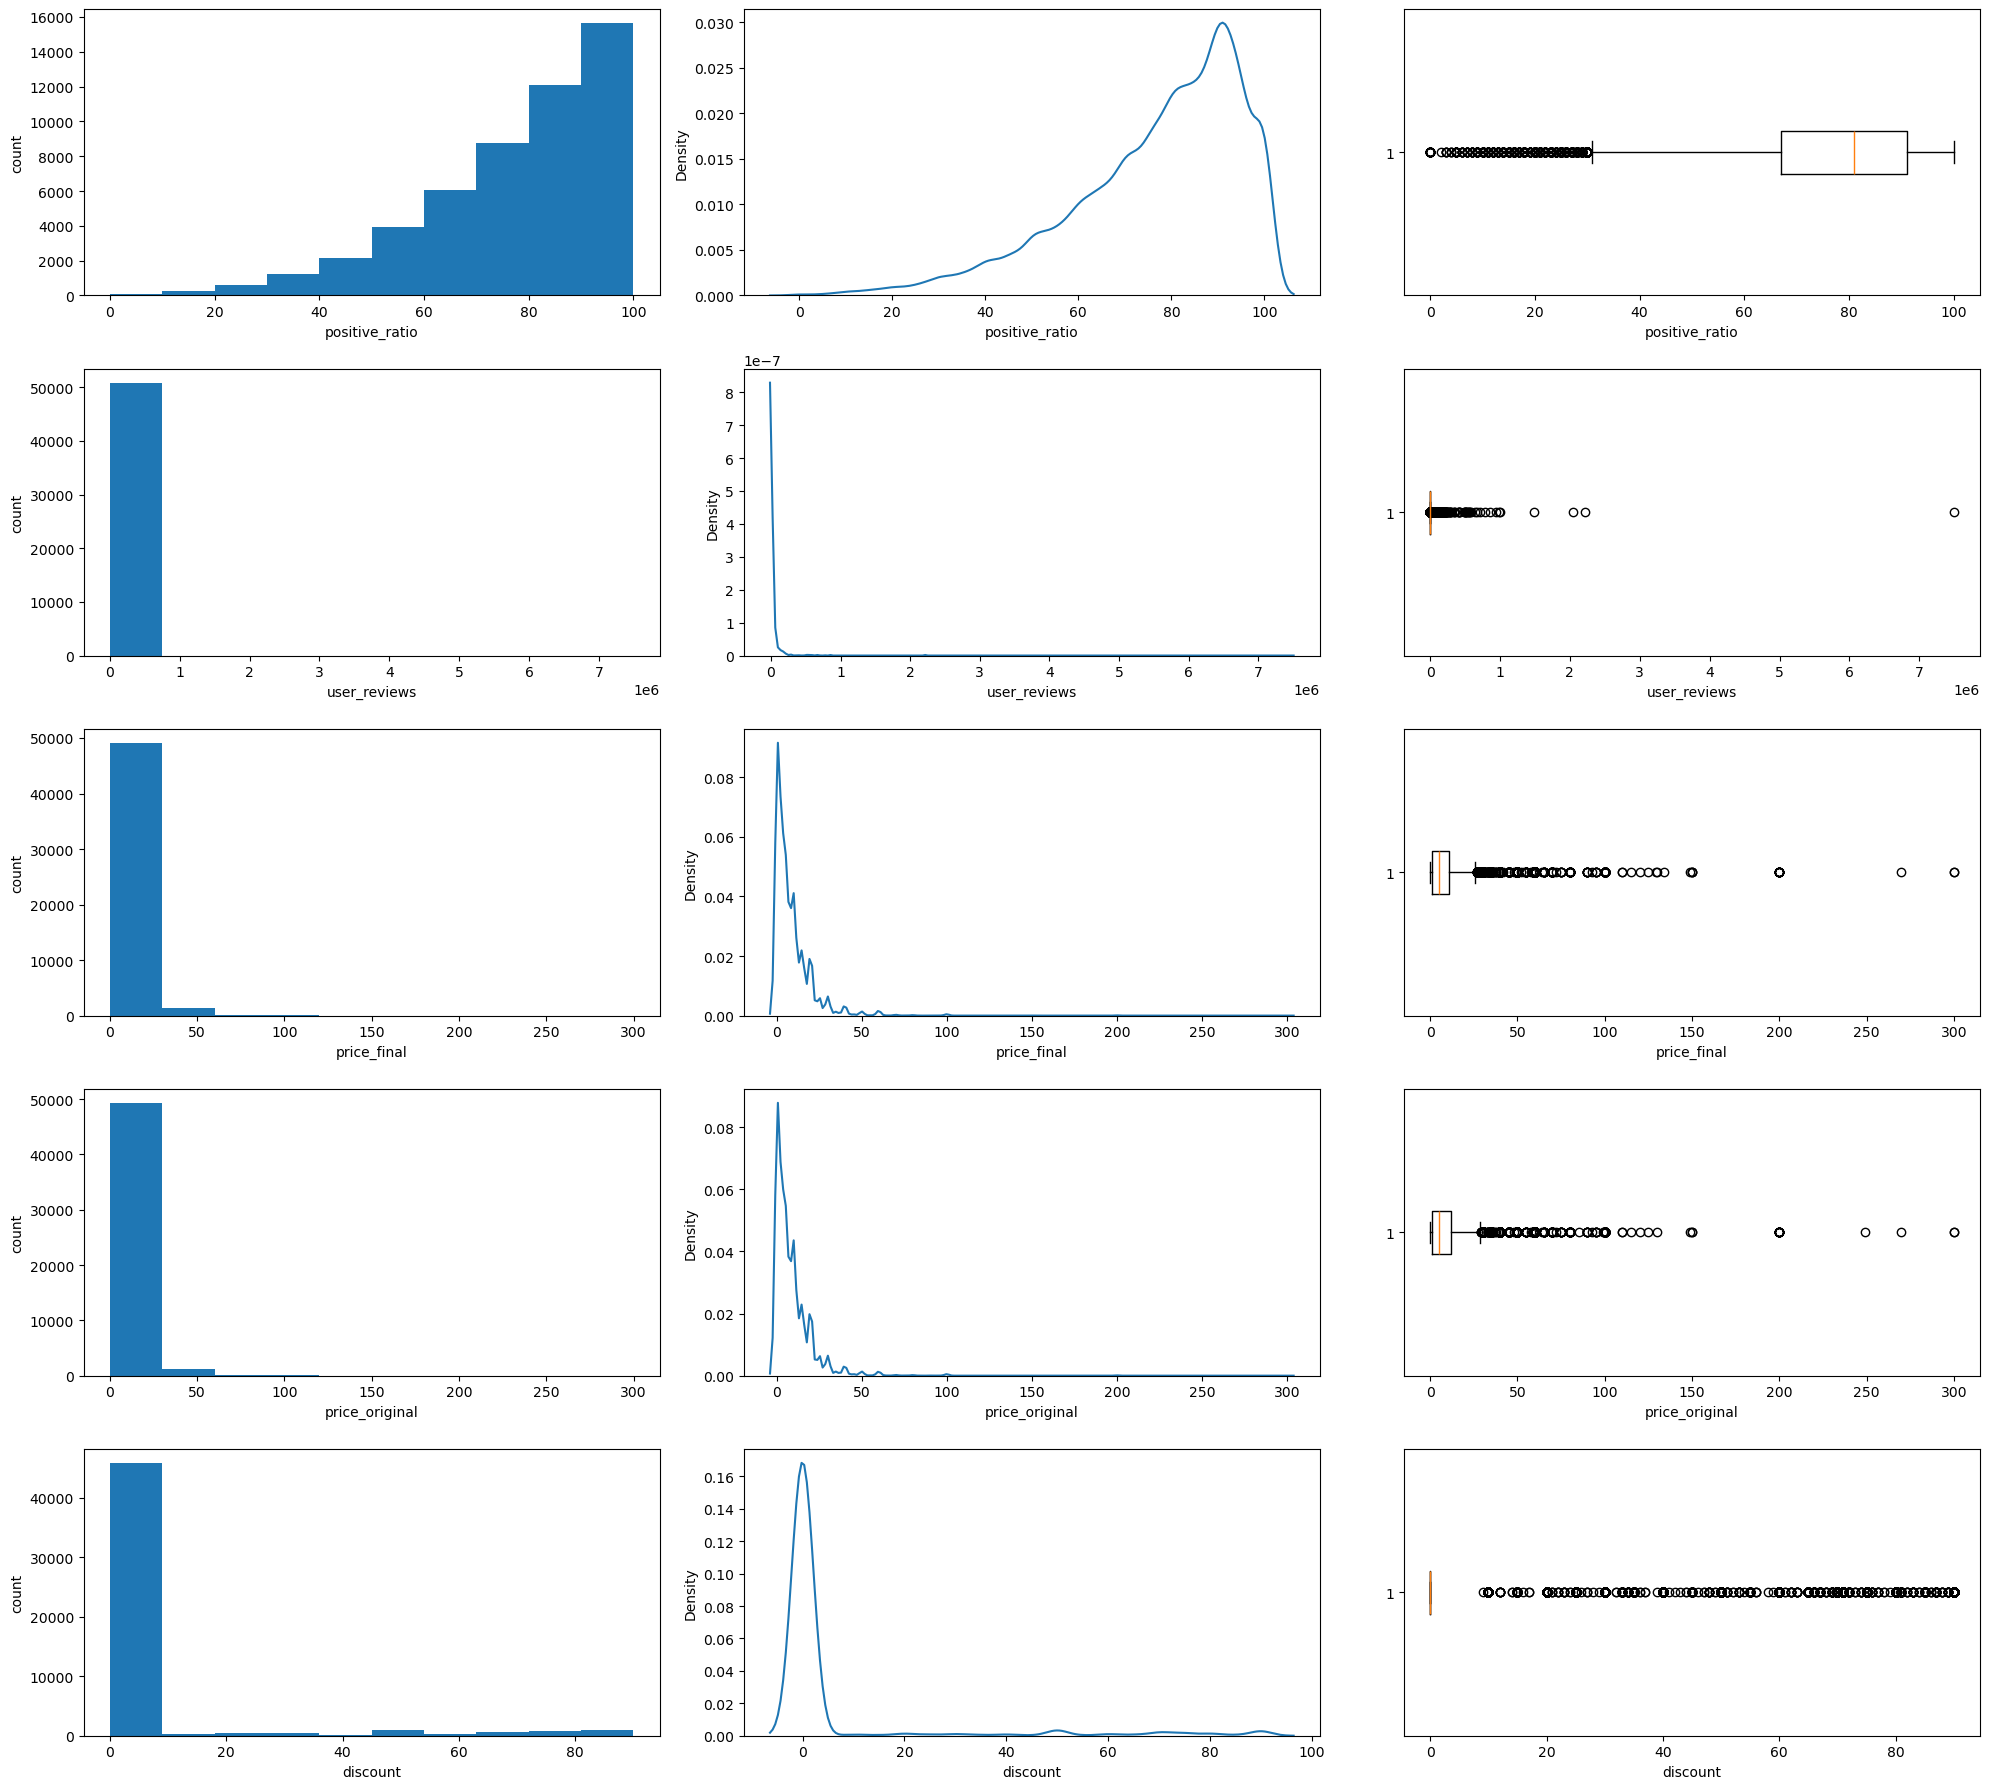

In [13]:
# Visualizations of numerical features
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount']

fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(20, 18))

for i, col in enumerate(num_cols):
    # histogram
    ax[i, 0].hist(games[col])
    ax[i, 0].set_xlabel(f"{col}")
    ax[i, 0].set_ylabel("count")
    
    # kde plot -- interpretable histogram
    sns.kdeplot(data=games, x=col, ax=ax[i, 1])

    # box plot -- for outliers
    ax[i, 2].boxplot(games[col], orientation='horizontal')
    ax[i, 2].set_xlabel(f"{col}")

plt.tight_layout()
plt.show()

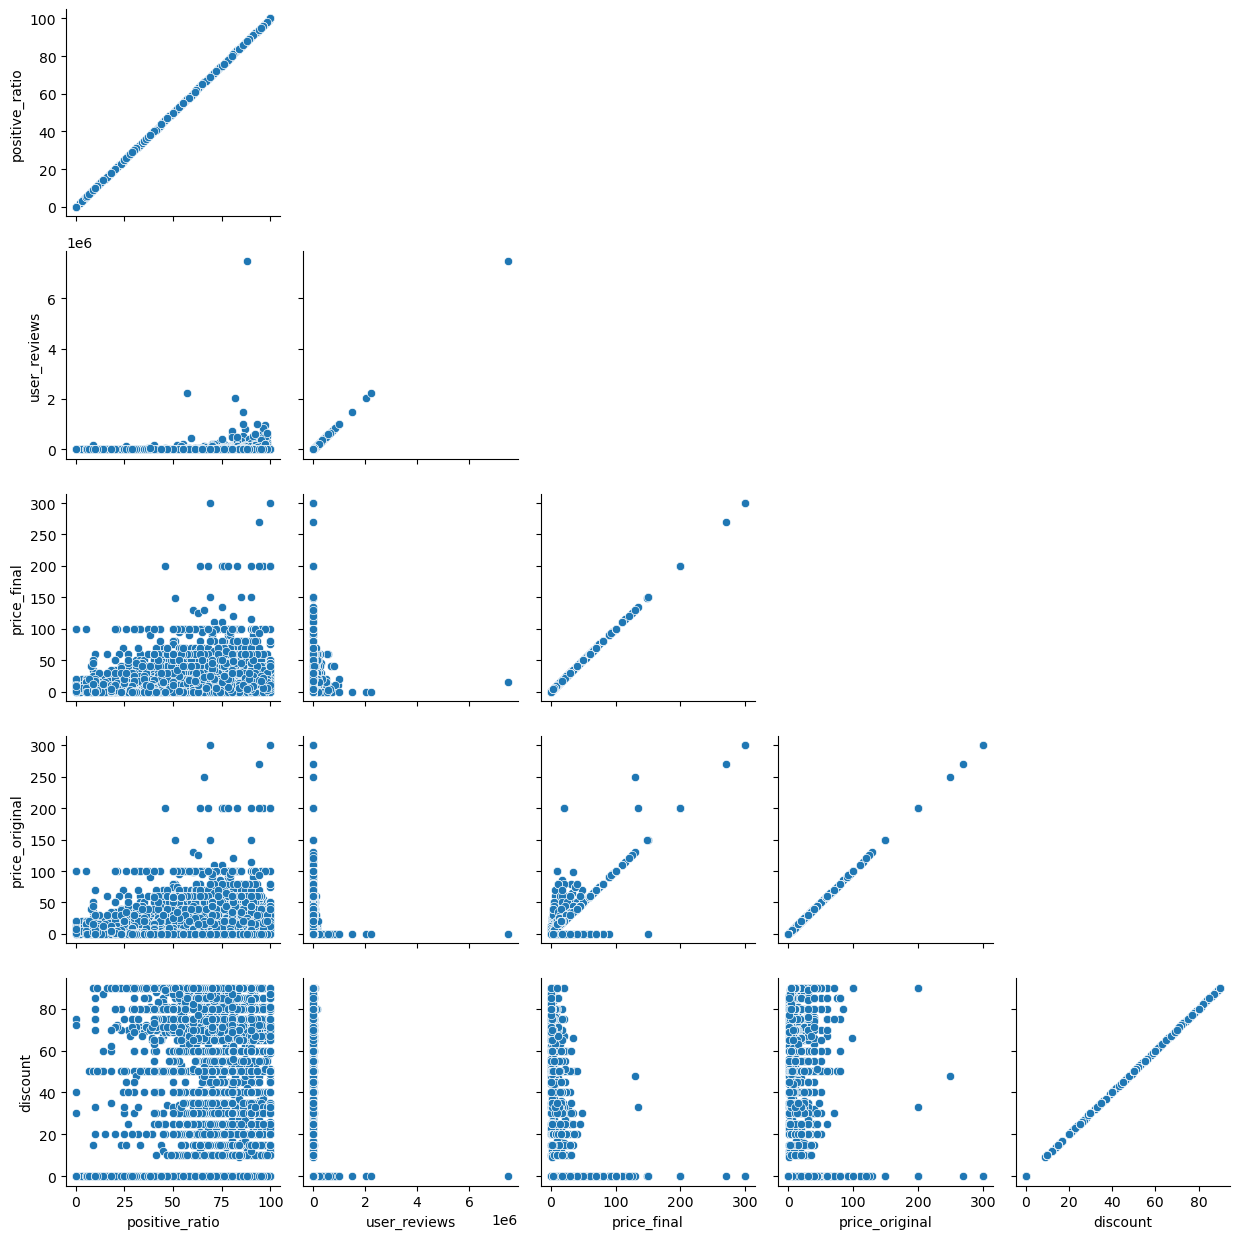

In [14]:
# Relationships between different numerical features shown via scatter plots.
sns.pairplot(data=games, vars=num_cols, kind='scatter', diag_kind=None, corner=True)
plt.tight_layout()
plt.show()

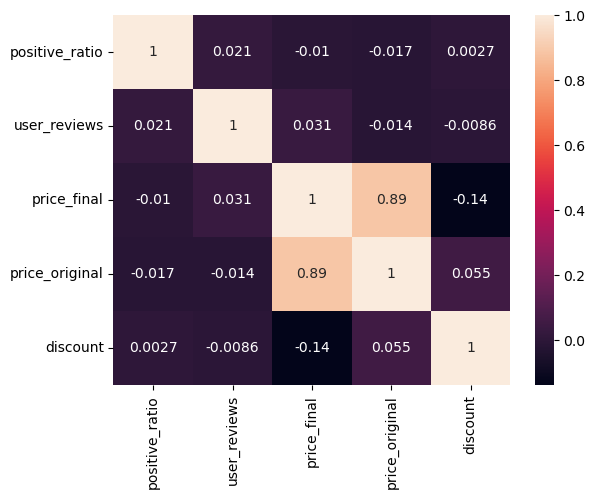

In [15]:
# To get relationships(mainly linear) in numbers, which are done visually above. Supporting each other.
sns.heatmap(games[num_cols].corr(), annot=True)
plt.show()

In [16]:
# So, some observations made and their corresponding actions to take, if any, are: {collaboratively discussed with GPPT}
# 1. positive_ratio is bounded(0-100), slightly left-skewed. No extreme issues. Hence, no tranformations or similar will be done.
# 2. user_reviews is extremely right-skewed. Many outliers as well, but are meaningful. Hence, need to do log transformation.
# 3. price_final is also right-skewed with some high-price outliers, which is typical economic distribution. Hence, log transformation.
# 4. price_original is the same as price-final. Also, both are highly correlated. Hence, dropping this feature being redundant.
# 5. discount is discrete in the sense that its mostly 0 and some sperad upto ~90. Weak linear reln. with others. Derived feature. Hence, no action to take.

# Though there are outliers present, they are not worth removing as they preserve signals such as popularity, prices, etc.

In [17]:
import numpy as np

games['user_reviews'] = np.log1p(games['user_reviews'])
games['price_final'] = np.log1p(games['price_final'])
games.drop(columns=['price_original'], inplace=True)
games

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,7.696213,2.396986,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,3.091042,1.383791,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,8.222285,2.771964,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,6.773080,2.771964,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,9.080801,2.564180,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,True,False,False,Very Positive,96,4.624973,3.135494,0.0,True
50868,1272080,PAYDAY 3,2023-09-21,True,False,False,Mostly Negative,38,10.290755,3.713572,0.0,True
50869,1402110,Eternights,2023-09-11,True,False,False,Very Positive,89,7.029088,3.433987,0.0,True
50870,2272250,Forgive Me Father 2,2023-10-19,True,False,False,Very Positive,95,4.418841,2.890372,0.0,True


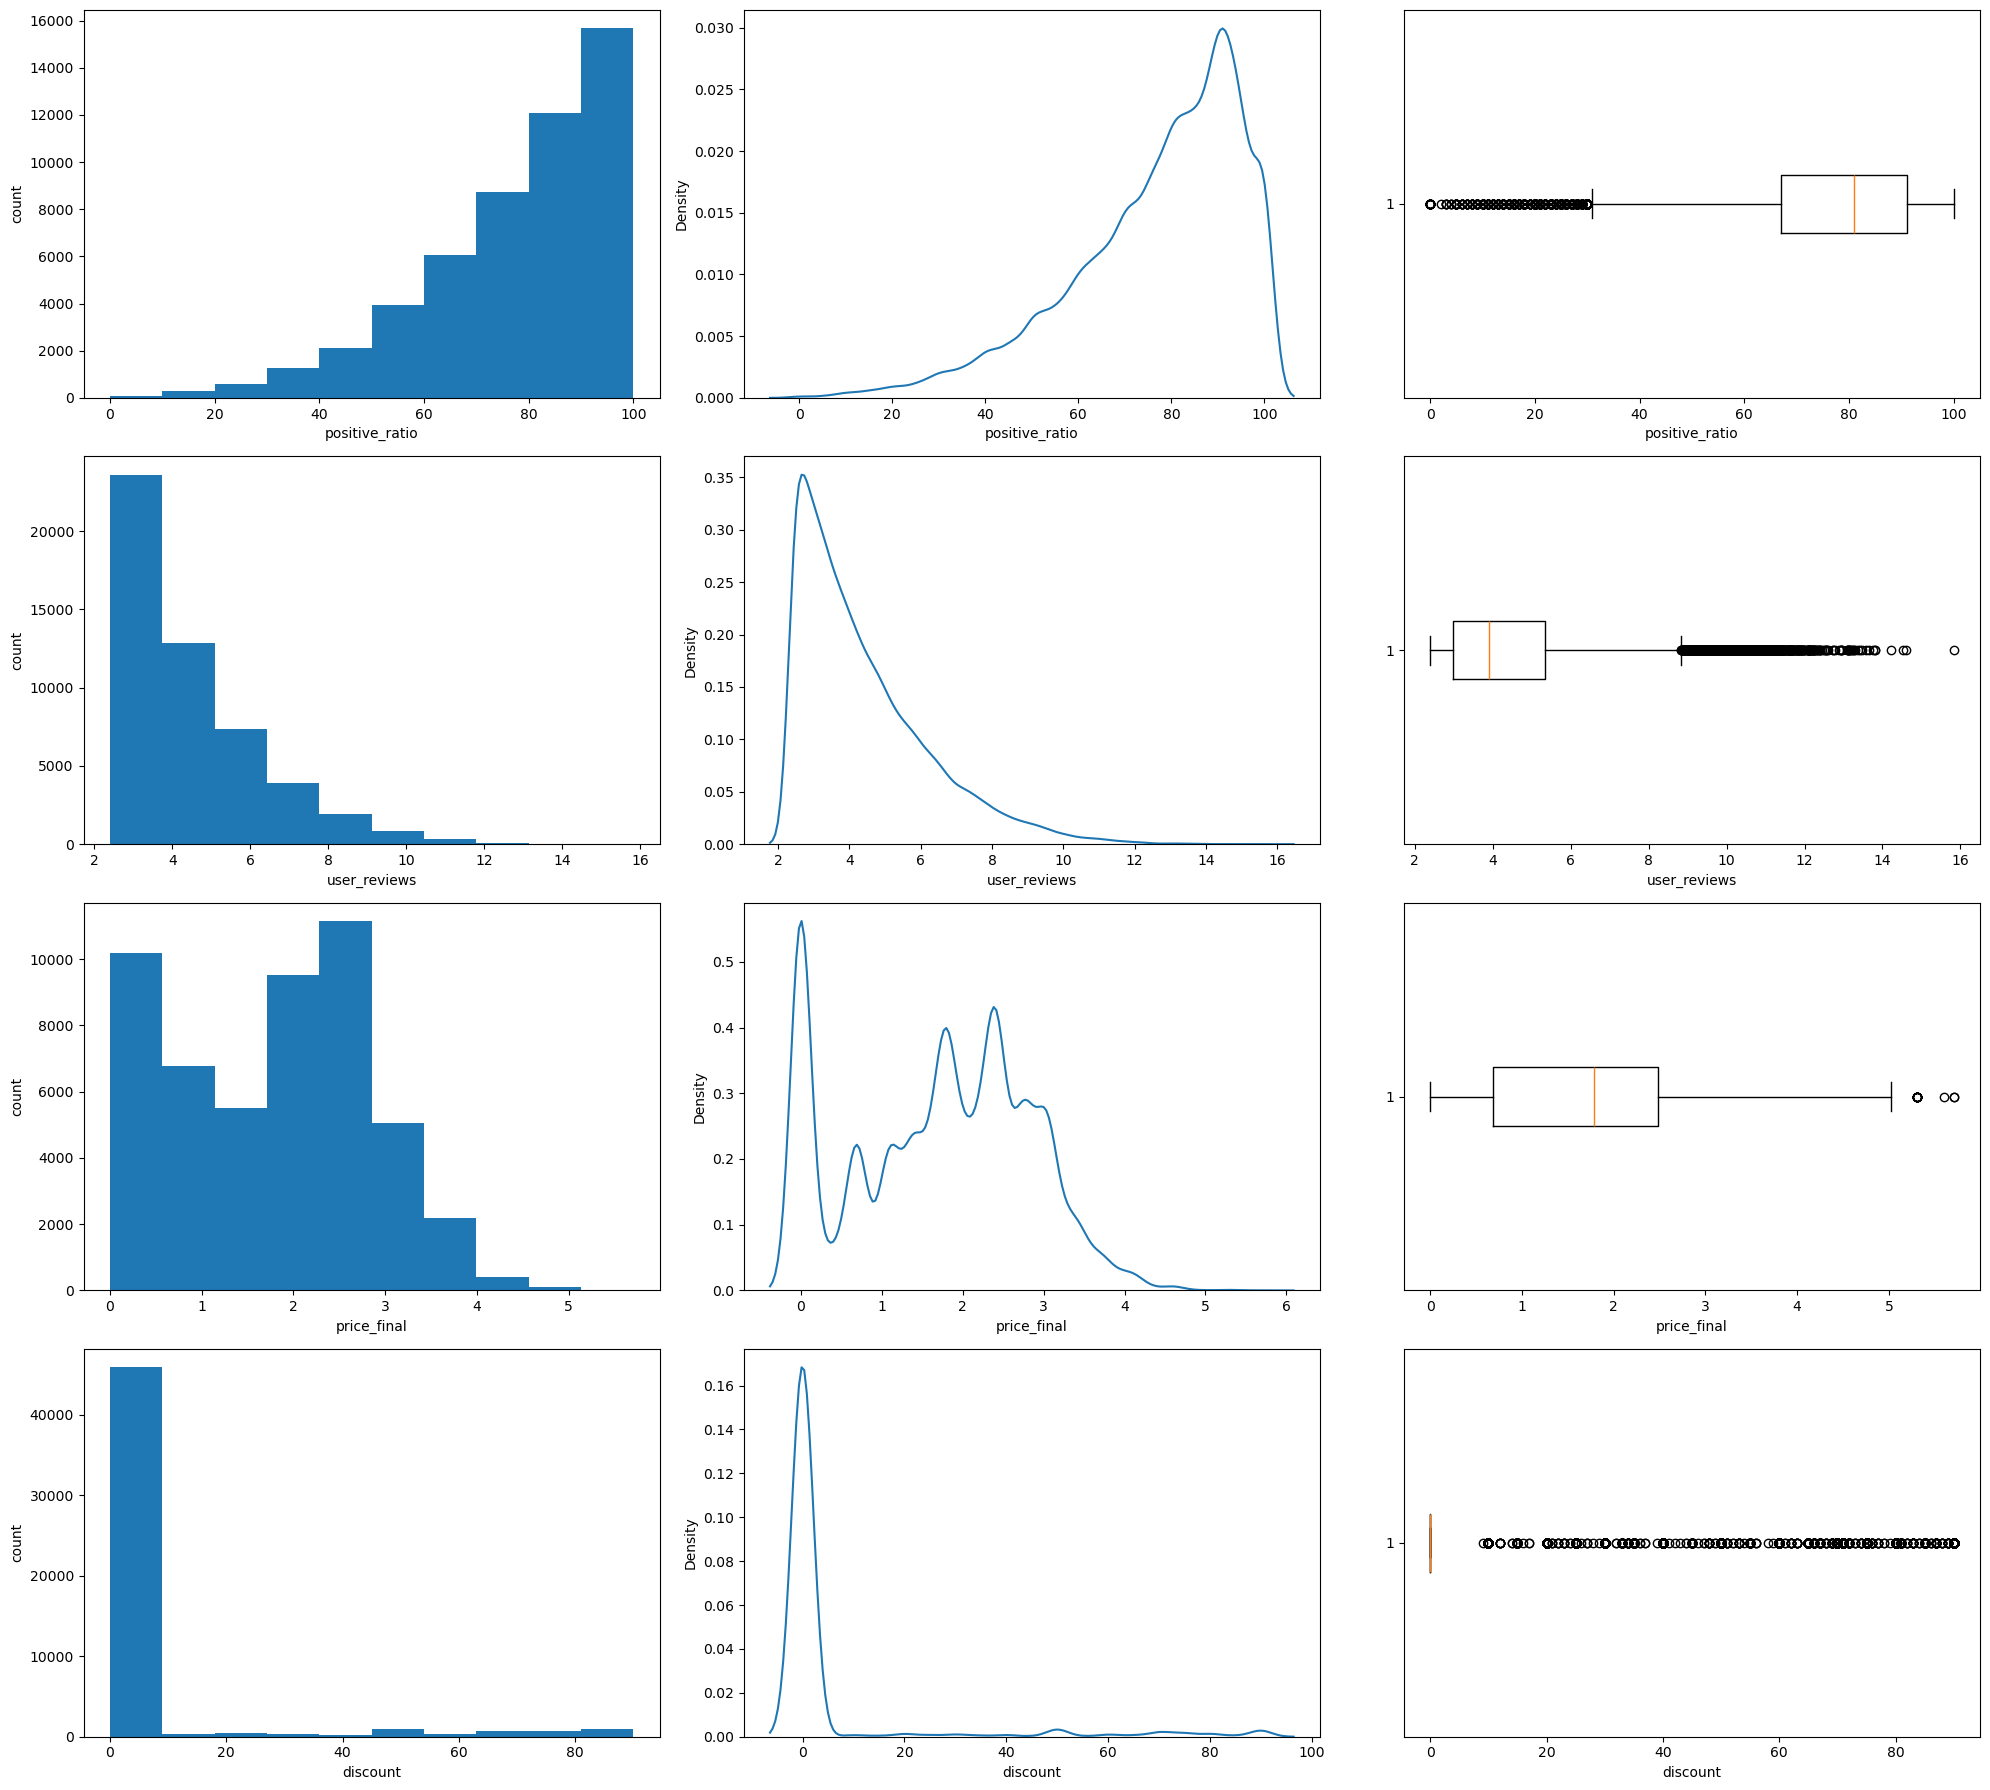

In [18]:
# Visualizations of numerical features after transformations
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['positive_ratio', 'user_reviews', 'price_final', 'discount']

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(20, 18))

for i, col in enumerate(num_cols):
    # histogram
    ax[i, 0].hist(games[col])
    ax[i, 0].set_xlabel(f"{col}")
    ax[i, 0].set_ylabel("count")
    
    # kde plot -- interpretable histogram
    sns.kdeplot(data=games, x=col, ax=ax[i, 1])

    # box plot -- for outliers
    ax[i, 2].boxplot(games[col], orientation='horizontal')
    ax[i, 2].set_xlabel(f"{col}")

plt.tight_layout()
plt.show()

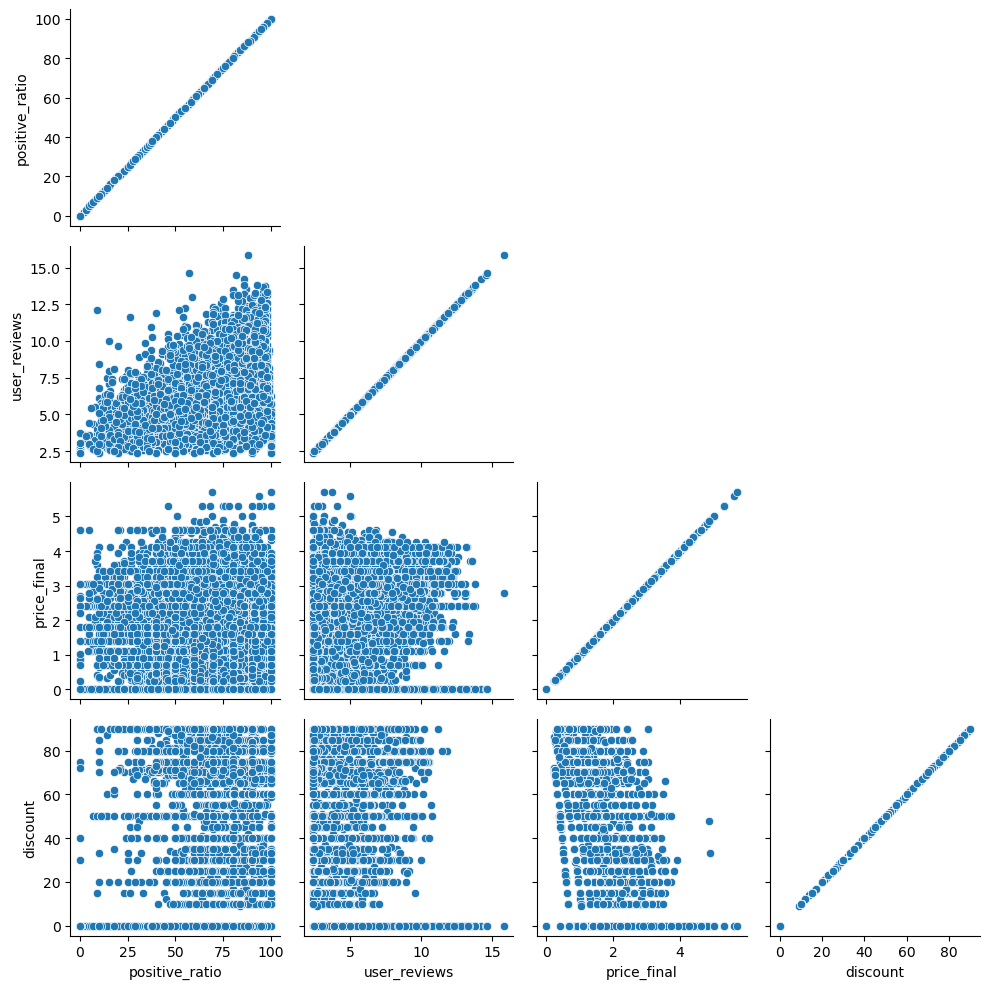

In [19]:
# Relationships between different numerical features shown via scatter plots.
sns.pairplot(data=games, vars=num_cols, kind='scatter', diag_kind=None, corner=True)
plt.tight_layout()
plt.show()

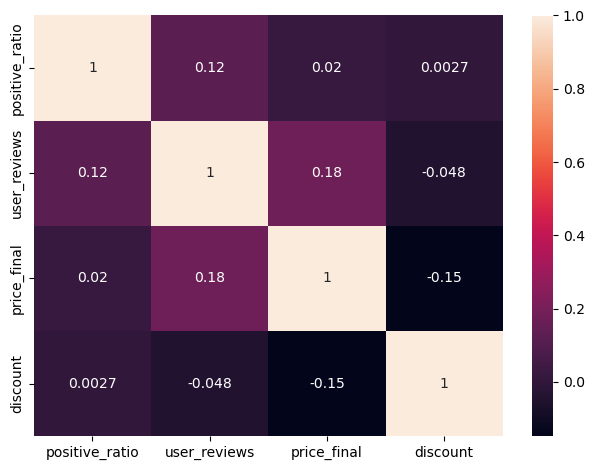

In [20]:
# To get relationships(mainly linear) in numbers, which are done visually above. Supporting each other.
sns.heatmap(games[num_cols].corr(), annot=True)
plt.tight_layout()
plt.show()

In [21]:
# The numerical features now look much more balanced.
# One insight is that discount is right-skewed with discreteness i.e., not continous in certain ranges within 0-100 range. Hence, it would be better to have the signal of whether the game has a discount along with its strength, normalized.
games['has_discount'] = (games['discount'] > 0).astype(int)
games['discount'] /= 100
games

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,7.696213,2.396986,0.0,True,0
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,3.091042,1.383791,0.0,True,0
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,8.222285,2.771964,0.0,True,0
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,6.773080,2.771964,0.0,True,0
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,9.080801,2.564180,0.0,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,True,False,False,Very Positive,96,4.624973,3.135494,0.0,True,0
50868,1272080,PAYDAY 3,2023-09-21,True,False,False,Mostly Negative,38,10.290755,3.713572,0.0,True,0
50869,1402110,Eternights,2023-09-11,True,False,False,Very Positive,89,7.029088,3.433987,0.0,True,0
50870,2272250,Forgive Me Father 2,2023-10-19,True,False,False,Very Positive,95,4.418841,2.890372,0.0,True,0


In [22]:
games.rating.value_counts()

rating
Positive                   13502
Very Positive              13139
Mixed                      12156
Mostly Positive             8738
Mostly Negative             1849
Overwhelmingly Positive     1110
Negative                     303
Very Negative                 60
Overwhelmingly Negative       14
Name: count, dtype: int64

In [23]:
# Done with numerical features now. Onto categorical features.

# Converting boolean features to numerical as in from true/false to 1/0
bool_cols = ['win', 'mac', 'linux', 'steam_deck']
games[bool_cols] = games[bool_cols].astype(int)

# Encoding the rating column using pandas' get_dummies() function
games = pd.get_dummies(games, columns=['rating'], dtype=int)
games

,app_id,title,date_release,win,mac,linux,positive_ratio,user_reviews,price_final,discount,...,has_discount,rating_Mixed,rating_Mostly Negative,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive
0,13500,Prince of Persia: Warrior Within™,2008-11-21,1,0,0,84,7.696213,2.396986,0.0,...,0,0,0,0,0,0,0,0,0,1
1,22364,BRINK: Agents of Change,2011-08-03,1,0,0,85,3.091042,1.383791,0.0,...,0,0,0,0,0,0,0,1,0,0
2,113020,Monaco: What's Yours Is Mine,2013-04-24,1,1,1,92,8.222285,2.771964,0.0,...,0,0,0,0,0,0,0,0,0,1
3,226560,Escape Dead Island,2014-11-18,1,0,0,61,6.773080,2.771964,0.0,...,0,1,0,0,0,0,0,0,0,0
4,249050,Dungeon of the ENDLESS™,2014-10-27,1,1,0,88,9.080801,2.564180,0.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,2023-09-28,1,0,0,96,4.624973,3.135494,0.0,...,0,0,0,0,0,0,0,0,0,1
50868,1272080,PAYDAY 3,2023-09-21,1,0,0,38,10.290755,3.713572,0.0,...,0,0,1,0,0,0,0,0,0,0
50869,1402110,Eternights,2023-09-11,1,0,0,89,7.029088,3.433987,0.0,...,0,0,0,0,0,0,0,0,0,1
50870,2272250,Forgive Me Father 2,2023-10-19,1,0,0,95,4.418841,2.890372,0.0,...,0,0,0,0,0,0,0,0,0,1


In [24]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50871 entries, 0 to 50871
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   app_id                          50871 non-null  int64         
 1   title                           50871 non-null  object        
 2   date_release                    50871 non-null  datetime64[ns]
 3   win                             50871 non-null  int64         
 4   mac                             50871 non-null  int64         
 5   linux                           50871 non-null  int64         
 6   positive_ratio                  50871 non-null  int64         
 7   user_reviews                    50871 non-null  float64       
 8   price_final                     50871 non-null  float64       
 9   discount                        50871 non-null  float64       
 10  steam_deck                      50871 non-null  int64         
 11  has_dis

In [25]:
# Converting the date_column to necessary date features(separating the 3)
games['release_year'] = games['date_release'].dt.year
games['release_month'] = games['date_release'].dt.month
games['release_day'] = games['date_release'].dt.day
games.drop(columns=['date_release'], inplace=True)
games

,app_id,title,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,...,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive,release_year,release_month,release_day
0,13500,Prince of Persia: Warrior Within™,1,0,0,84,7.696213,2.396986,0.0,1,...,0,0,0,0,0,0,1,2008,11,21
1,22364,BRINK: Agents of Change,1,0,0,85,3.091042,1.383791,0.0,1,...,0,0,0,0,1,0,0,2011,8,3
2,113020,Monaco: What's Yours Is Mine,1,1,1,92,8.222285,2.771964,0.0,1,...,0,0,0,0,0,0,1,2013,4,24
3,226560,Escape Dead Island,1,0,0,61,6.773080,2.771964,0.0,1,...,0,0,0,0,0,0,0,2014,11,18
4,249050,Dungeon of the ENDLESS™,1,1,0,88,9.080801,2.564180,0.0,1,...,0,0,0,0,0,0,1,2014,10,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,I Expect You To Die 3: Cog in the Machine,1,0,0,96,4.624973,3.135494,0.0,1,...,0,0,0,0,0,0,1,2023,9,28
50868,1272080,PAYDAY 3,1,0,0,38,10.290755,3.713572,0.0,1,...,0,0,0,0,0,0,0,2023,9,21
50869,1402110,Eternights,1,0,0,89,7.029088,3.433987,0.0,1,...,0,0,0,0,0,0,1,2023,9,11
50870,2272250,Forgive Me Father 2,1,0,0,95,4.418841,2.890372,0.0,1,...,0,0,0,0,0,0,1,2023,10,19


In [26]:
# The title column is not used as a feature, per se, in its raw text form. So, no value provided. Hence, dropping it.
games.drop(columns=['title'], inplace=True)
games

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive,release_year,release_month,release_day
0,13500,1,0,0,84,7.696213,2.396986,0.0,1,0,...,0,0,0,0,0,0,1,2008,11,21
1,22364,1,0,0,85,3.091042,1.383791,0.0,1,0,...,0,0,0,0,1,0,0,2011,8,3
2,113020,1,1,1,92,8.222285,2.771964,0.0,1,0,...,0,0,0,0,0,0,1,2013,4,24
3,226560,1,0,0,61,6.773080,2.771964,0.0,1,0,...,0,0,0,0,0,0,0,2014,11,18
4,249050,1,1,0,88,9.080801,2.564180,0.0,1,0,...,0,0,0,0,0,0,1,2014,10,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50867,2296380,1,0,0,96,4.624973,3.135494,0.0,1,0,...,0,0,0,0,0,0,1,2023,9,28
50868,1272080,1,0,0,38,10.290755,3.713572,0.0,1,0,...,0,0,0,0,0,0,0,2023,9,21
50869,1402110,1,0,0,89,7.029088,3.433987,0.0,1,0,...,0,0,0,0,0,0,1,2023,9,11
50870,2272250,1,0,0,95,4.418841,2.890372,0.0,1,0,...,0,0,0,0,0,0,1,2023,10,19


In [27]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50871 entries, 0 to 50871
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   app_id                          50871 non-null  int64  
 1   win                             50871 non-null  int64  
 2   mac                             50871 non-null  int64  
 3   linux                           50871 non-null  int64  
 4   positive_ratio                  50871 non-null  int64  
 5   user_reviews                    50871 non-null  float64
 6   price_final                     50871 non-null  float64
 7   discount                        50871 non-null  float64
 8   steam_deck                      50871 non-null  int64  
 9   has_discount                    50871 non-null  int64  
 10  rating_Mixed                    50871 non-null  int64  
 11  rating_Mostly Negative          50871 non-null  int64  
 12  rating_Mostly Positive          50871

In [28]:
# Converting data type precisions for memory and performance optimizations {Syntax by GPT for less code}
games = games.apply(pd.to_numeric, downcast='float')
games = games.apply(pd.to_numeric, downcast='integer')
games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50871 entries, 0 to 50871
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   app_id                          50871 non-null  int32  
 1   win                             50871 non-null  int8   
 2   mac                             50871 non-null  int8   
 3   linux                           50871 non-null  int8   
 4   positive_ratio                  50871 non-null  int8   
 5   user_reviews                    50871 non-null  float32
 6   price_final                     50871 non-null  float32
 7   discount                        50871 non-null  float32
 8   steam_deck                      50871 non-null  int8   
 9   has_discount                    50871 non-null  int8   
 10  rating_Mixed                    50871 non-null  int8   
 11  rating_Mostly Negative          50871 non-null  int8   
 12  rating_Mostly Positive          50871

In [29]:
# The feature vectors for games are ready. Only the features from game information such as tags/genres are left to be merged.
# As no models are used for v0 so, no embeddings.
# Therefore, creating information-rich, text-based vectors.

In [30]:
games_metadata = pd.read_json("~/projects/game_recommender_system/v0/data/raw/games_metadata.json", lines=True)
games_metadata

,app_id,description,tags
0,13500,Enter the dark underworld of Prince of Persia ...,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,,[Action]
2,113020,Monaco: What's Yours Is Mine is a single playe...,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,Escape Dead Island is a Survival-Mystery adven...,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,Dungeon of the Endless is a Rogue-Like Dungeon...,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
...,...,...,...
50867,2296380,,[]
50868,1272080,,[]
50869,1402110,,[]
50870,2272250,Embark on a journey into the darkest nightmare...,"[Early Access, FPS, Action, Retro, First-Perso..."


In [31]:
# Need only tags/genres for games to create information-rich vectors. Hence, dropping description column.
games_metadata.drop(columns=['description'], inplace=True)
games_metadata

,app_id,tags
0,13500,"[Action, Adventure, Parkour, Third Person, Gre..."
1,22364,[Action]
2,113020,"[Co-op, Stealth, Indie, Heist, Local Co-Op, St..."
3,226560,"[Zombies, Adventure, Survival, Action, Third P..."
4,249050,"[Roguelike, Strategy, Tower Defense, Pixel Gra..."
...,...,...
50867,2296380,[]
50868,1272080,[]
50869,1402110,[]
50870,2272250,"[Early Access, FPS, Action, Retro, First-Perso..."


In [32]:
# Removing the square brackets [] from tags column for easier pre-processing.
games_metadata['tags'] = games_metadata.tags.astype(str)
games_metadata['tags'] = games_metadata.tags.str.replace('[', "")
games_metadata['tags'] = games_metadata.tags.str.replace(']', "")
games_metadata['tags'] = games_metadata.tags.str.strip()
games_metadata

,app_id,tags
0,13500,"'Action', 'Adventure', 'Parkour', 'Third Perso..."
1,22364,'Action'
2,113020,"'Co-op', 'Stealth', 'Indie', 'Heist', 'Local C..."
3,226560,"'Zombies', 'Adventure', 'Survival', 'Action', ..."
4,249050,"'Roguelike', 'Strategy', 'Tower Defense', 'Pix..."
...,...,...
50867,2296380,
50868,1272080,
50869,1402110,
50870,2272250,"'Early Access', 'FPS', 'Action', 'Retro', 'Fir..."


In [33]:
print(games_metadata.app_id.duplicated().value_counts())
games_metadata.app_id.isnull().value_counts()

app_id
False    50872
Name: count, dtype: int64


app_id
False    50872
Name: count, dtype: int64

In [34]:
temp = games_metadata[games_metadata.tags == ""]
temp

,app_id,tags
33,371970,
214,2277010,
219,1600150,
224,222573,
287,919640,
...,...,...
50866,2362300,
50867,2296380,
50868,1272080,
50869,1402110,


In [35]:
games[games.app_id.isin(temp.app_id)]

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive,release_year,release_month,release_day
33,371970,1,1,1,92,8.219865,3.044523,0.0,1,0,...,0,0,0,0,0,0,1,2015,6,23
214,2277010,0,0,0,100,3.332205,0.000000,0.0,1,0,...,0,0,0,0,1,0,0,2023,1,30
219,1600150,0,0,0,98,4.584968,1.607436,0.0,1,0,...,0,0,0,0,0,0,1,2021,4,23
224,222573,1,0,0,100,2.944439,3.044046,0.0,1,0,...,0,0,0,0,1,0,0,2016,4,28
287,919640,1,0,0,79,8.755265,3.713572,0.0,1,0,...,1,0,0,0,0,0,0,2019,6,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50866,2362300,1,0,0,65,5.863631,3.931826,0.0,1,0,...,0,0,0,0,0,0,0,2023,9,26
50867,2296380,1,0,0,96,4.624973,3.135494,0.0,1,0,...,0,0,0,0,0,0,1,2023,9,28
50868,1272080,1,0,0,38,10.290754,3.713572,0.0,1,0,...,0,0,0,0,0,0,0,2023,9,21
50869,1402110,1,0,0,89,7.029088,3.433987,0.0,1,0,...,0,0,0,0,0,0,1,2023,9,11


In [36]:
# These 1244 rows do not have any tags. And, since it is a relatively small number with its presence in both datasets, the best option is to remove all of them from both.
games.drop(temp.index, inplace=True)
games_metadata.drop(temp.index, inplace=True)

In [37]:
print(games_metadata[games_metadata.tags == ""])
games[games.app_id.isin(temp.app_id)]

Empty DataFrame
Columns: [app_id, tags]
Index: []


,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive,release_year,release_month,release_day


In [38]:
# Further cleaning of the tags column for punctuations to do feature extraction based on text
import string
games_metadata['tags'] = games_metadata['tags'].apply(lambda text: text.translate(str.maketrans('', '', string.punctuation)))
games_metadata['tags'] = games_metadata.tags.str.strip()
games_metadata = games_metadata.reset_index(drop=True)
games_metadata

,app_id,tags
0,13500,Action Adventure Parkour Third Person Great So...
1,22364,Action
2,113020,Coop Stealth Indie Heist Local CoOp Strategy O...
3,226560,Zombies Adventure Survival Action Third Person...
4,249050,Roguelike Strategy Tower Defense Pixel Graphic...
...,...,...
49623,2455060,RPG Indie Nudity Action Roguelike Female Prota...
49624,1138640,Early Access Life Sim City Builder Immersive S...
49625,2515460,Strategy Indie Simulation
49626,1687000,Side Scroller Beat em up Sandbox Martial Arts ...


In [39]:
# Text feature extraction from tags column using TF-IDF. Because want to consider some importance of different genres, which can be present infrequently.
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tags_feature_vectors = vectorizer.fit_transform(games_metadata['tags'])
tags = pd.DataFrame(tags_feature_vectors.toarray())
tags

,0,1,2,3,4,5,6,7,8,9,...,469,470,471,472,473,474,475,476,477,478
0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.153681,0.0,0.0,0.000000
1,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.000000,0.0,0.0,0.113747,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.181431,0.0,0.0,0.241193
4,0.000000,0.0,0.0,0.119891,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49623,0.000000,0.0,0.0,0.000000,0.0,0.290840,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49624,0.000000,0.0,0.0,0.000000,0.0,0.128899,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.148963,0.0,0.0,0.000000
49625,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49626,0.233495,0.0,0.0,0.110995,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.157375,0.0,0.0,0.000000


In [40]:
games = games.reset_index(drop=True)
games

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,rating_Mostly Positive,rating_Negative,rating_Overwhelmingly Negative,rating_Overwhelmingly Positive,rating_Positive,rating_Very Negative,rating_Very Positive,release_year,release_month,release_day
0,13500,1,0,0,84,7.696213,2.396986,0.0,1,0,...,0,0,0,0,0,0,1,2008,11,21
1,22364,1,0,0,85,3.091043,1.383791,0.0,1,0,...,0,0,0,0,1,0,0,2011,8,3
2,113020,1,1,1,92,8.222285,2.771964,0.0,1,0,...,0,0,0,0,0,0,1,2013,4,24
3,226560,1,0,0,61,6.773080,2.771964,0.0,1,0,...,0,0,0,0,0,0,0,2014,11,18
4,249050,1,1,0,88,9.080801,2.564180,0.0,1,0,...,0,0,0,0,0,0,1,2014,10,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49622,2455060,1,0,0,94,6.204558,2.564949,0.0,1,0,...,0,0,0,0,0,0,1,2023,7,31
49623,1138640,1,0,0,61,5.517453,2.890372,0.0,1,0,...,0,0,0,0,0,0,0,2023,9,27
49624,2515460,1,1,1,67,4.394449,1.791759,0.0,1,0,...,0,0,0,0,0,0,0,2023,8,24
49625,1687000,1,0,0,79,5.883322,3.044523,0.0,1,0,...,1,0,0,0,0,0,0,2023,9,14


In [41]:
# This is the same duplicated game that was removed from games set. One of the two was kept.
# Since this is now not present in games, take the inner join while concat/merging tags and games set.
games_metadata[~games_metadata.app_id.isin(games.app_id)]

,app_id,tags
38096,329270,Strategy RPG


In [42]:
final_games_transformed = pd.concat([games, tags], axis=1, join='inner')
final_games_transformed

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,469,470,471,472,473,474,475,476,477,478
0,13500,1,0,0,84,7.696213,2.396986,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.153681,0.0,0.0,0.000000
1,22364,1,0,0,85,3.091043,1.383791,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,113020,1,1,1,92,8.222285,2.771964,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,226560,1,0,0,61,6.773080,2.771964,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.181431,0.0,0.0,0.241193
4,249050,1,1,0,88,9.080801,2.564180,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49622,2455060,1,0,0,94,6.204558,2.564949,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49623,1138640,1,0,0,61,5.517453,2.890372,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49624,2515460,1,1,1,67,4.394449,1.791759,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.148963,0.0,0.0,0.000000
49625,1687000,1,0,0,79,5.883322,3.044523,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000


In [43]:
final_games_transformed[final_games_transformed.app_id == 329270]

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,469,470,471,472,473,474,475,476,477,478


In [44]:
final_games_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49627 entries, 0 to 49626
Columns: 501 entries, app_id to 478
dtypes: float32(3), float64(479), int16(1), int32(1), int8(17)
memory usage: 183.0 MB


In [45]:
final_games_transformed = final_games_transformed.apply(pd.to_numeric, downcast='float')
final_games_transformed = final_games_transformed.apply(pd.to_numeric, downcast='integer')
final_games_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49627 entries, 0 to 49626
Columns: 501 entries, app_id to 478
dtypes: float32(482), int16(1), int32(1), int8(17)
memory usage: 92.3 MB


In [46]:
final_games_transformed

,app_id,win,mac,linux,positive_ratio,user_reviews,price_final,discount,steam_deck,has_discount,...,469,470,471,472,473,474,475,476,477,478
0,13500,1,0,0,84,7.696213,2.396986,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.153681,0.0,0.0,0.000000
1,22364,1,0,0,85,3.091043,1.383791,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,113020,1,1,1,92,8.222285,2.771964,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,226560,1,0,0,61,6.773080,2.771964,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.181431,0.0,0.0,0.241193
4,249050,1,1,0,88,9.080801,2.564180,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49622,2455060,1,0,0,94,6.204558,2.564949,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49623,1138640,1,0,0,61,5.517453,2.890372,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
49624,2515460,1,1,1,67,4.394449,1.791759,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.148963,0.0,0.0,0.000000
49625,1687000,1,0,0,79,5.883322,3.044523,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000


In [47]:
# The game feature vectors are now ready. Hence, exporting them in a csv file.
final_games_transformed.to_csv("~/projects/game_recommender_system/v0/data/processed/processed_games_v0.csv")

In [1]:
# Now, loading and processing the recommendations(or, interactions) dataset.
# For user simulation per v0.
import pandas as pd

# Because kernel crashes due to memory issue by large dataset. Hence, loading by chunking and random sampling.
# Code given by GPT
chunks = []
for chunk in pd.read_csv('~/projects/game_recommender_system/v0/data/raw/recommendations.csv', chunksize=100_000):
    chunks.append(chunk.sample(frac=0.15, random_state=42)) # for reproducibility

interactions = pd.concat(chunks)

del chunks

In [2]:
# Working with 15% of the original dataset size.
interactions

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
75721,431960,0,0,2022-03-07,True,136.0,5029913,75721
80184,275850,2,0,2018-11-26,True,62.8,7170282,80184
19864,1938090,0,0,2022-12-19,False,22.1,13073598,19864
76699,526870,0,0,2020-06-14,True,27.3,13002277,76699
92991,252490,0,0,2019-07-03,False,5.8,4130104,92991
...,...,...,...,...,...,...,...,...
41134026,1057090,0,0,2022-12-29,True,31.0,1235278,41134026
41110689,729040,0,2,2019-11-27,True,8.0,5569834,41110689
41112986,633230,0,0,2021-11-26,True,84.0,13056692,41112986
41115537,578330,0,0,2022-12-11,True,92.0,3668243,41115537


In [3]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173219 entries, 75721 to 41127342
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   app_id          int64  
 1   helpful         int64  
 2   funny           int64  
 3   date            object 
 4   is_recommended  bool   
 5   hours           float64
 6   user_id         int64  
 7   review_id       int64  
dtypes: bool(1), float64(1), int64(5), object(1)
memory usage: 382.7+ MB


In [4]:
# For memory and performance optimizations, changing the precision automatically with appropriateness.
interactions['date'] = pd.to_datetime(interactions['date'])
interactions['is_recommended'] = interactions['is_recommended'].astype('int8')

In [5]:
interactions = interactions.apply(pd.to_numeric, downcast='float')
interactions = interactions.apply(pd.to_numeric, downcast='integer')

/home/ritishu/miniconda3/envs/game/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:377: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)


In [6]:
interactions['date'] = pd.to_datetime(interactions['date'])
interactions.reset_index(drop=True)

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,431960,0,0,2022-03-07,1,136.000000,5029913,75721
1,275850,2,0,2018-11-26,1,62.799999,7170282,80184
2,1938090,0,0,2022-12-19,0,22.100000,13073598,19864
3,526870,0,0,2020-06-14,1,27.299999,13002277,76699
4,252490,0,0,2019-07-03,0,5.800000,4130104,92991
...,...,...,...,...,...,...,...,...
6173214,1057090,0,0,2022-12-29,1,31.000000,1235278,41134026
6173215,729040,0,2,2019-11-27,1,8.000000,5569834,41110689
6173216,633230,0,0,2021-11-26,1,84.000000,13056692,41112986
6173217,578330,0,0,2022-12-11,1,92.000000,3668243,41115537


In [7]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173219 entries, 75721 to 41127342
Data columns (total 8 columns):
 #   Column          Dtype         
---  ------          -----         
 0   app_id          int32         
 1   helpful         int16         
 2   funny           int16         
 3   date            datetime64[ns]
 4   is_recommended  int8          
 5   hours           float32       
 6   user_id         int32         
 7   review_id       int32         
dtypes: datetime64[ns](1), float32(1), int16(2), int32(3), int8(1)
memory usage: 217.8 MB


In [8]:
interactions['publish_year'] = interactions.date.dt.year
interactions['publish_month'] = interactions.date.dt.month
interactions['publish_day'] = interactions.date.dt.day
interactions.drop(columns=['date'], inplace=True)
interactions = interactions.apply(pd.to_numeric, downcast='integer')

# The index of the set and review_id are the same. Hence, dropping that column and resetting the index.
interactions.drop(columns=['review_id'], inplace=True)
interactions.reset_index(drop=True, inplace=True)
interactions

,app_id,helpful,funny,is_recommended,hours,user_id,publish_year,publish_month,publish_day
0,431960,0,0,1,136.000000,5029913,2022,3,7
1,275850,2,0,1,62.799999,7170282,2018,11,26
2,1938090,0,0,0,22.100000,13073598,2022,12,19
3,526870,0,0,1,27.299999,13002277,2020,6,14
4,252490,0,0,0,5.800000,4130104,2019,7,3
...,...,...,...,...,...,...,...,...,...
6173214,1057090,0,0,1,31.000000,1235278,2022,12,29
6173215,729040,0,2,1,8.000000,5569834,2019,11,27
6173216,633230,0,0,1,84.000000,13056692,2021,11,26
6173217,578330,0,0,1,92.000000,3668243,2022,12,11


In [9]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6173219 entries, 0 to 6173218
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   app_id          int32  
 1   helpful         int16  
 2   funny           int16  
 3   is_recommended  int8   
 4   hours           float32
 5   user_id         int32  
 6   publish_year    int16  
 7   publish_month   int8   
 8   publish_day     int8   
dtypes: float32(1), int16(3), int32(2), int8(3)
memory usage: 123.6 MB


In [10]:
print(interactions.isna().value_counts())
interactions.isnull().value_counts()

app_id  helpful  funny  is_recommended  hours  user_id  publish_year  publish_month  publish_day
False   False    False  False           False  False    False         False          False          6173219
Name: count, dtype: int64


app_id  helpful  funny  is_recommended  hours  user_id  publish_year  publish_month  publish_day
False   False    False  False           False  False    False         False          False          6173219
Name: count, dtype: int64

In [11]:
print(interactions.app_id.duplicated().value_counts())
interactions.user_id.duplicated().value_counts()

app_id
True     6139084
False      34135
Name: count, dtype: int64


user_id
False    3993287
True     2179932
Name: count, dtype: int64

In [12]:
# This duplicacy is expected because these are interactions hence, mamy-to-many mapping between different games and users.
# However, giving a look at it for any possible redundancy.

In [13]:
interactions[interactions.duplicated(['app_id'])].sort_values('app_id')

,app_id,helpful,funny,is_recommended,hours,user_id,publish_year,publish_month,publish_day
4022978,10,0,0,1,36.799999,9444153,2013,12,5
2655514,10,2,0,1,999.200012,9172138,2017,4,12
4104223,10,0,0,1,149.000000,9360571,2017,12,5
3541597,10,0,0,1,838.700012,3973588,2021,1,8
4127145,10,0,0,1,21.600000,4902901,2017,11,11
...,...,...,...,...,...,...,...,...,...
4342391,2241860,9,0,1,53.200001,954623,2022,12,24
5590021,2245840,0,0,1,0.800000,12783330,2022,12,28
5656040,2245840,0,0,0,0.200000,7148662,2022,12,30
5683807,2245840,4,0,1,3.100000,3039344,2022,12,27


In [14]:
interactions[interactions.duplicated(['user_id'])].sort_values('user_id')

,app_id,helpful,funny,is_recommended,hours,user_id,publish_year,publish_month,publish_day
5736042,451880,2,0,0,6.500000,0,2017,6,11
4848533,402840,3,0,1,157.399994,0,2019,11,27
4365661,267060,6,0,0,11.500000,0,2014,9,2
5666887,339160,3,0,0,13.000000,0,2017,6,16
3305846,1454400,6,2,1,762.599976,0,2022,2,18
...,...,...,...,...,...,...,...,...,...
2186875,760160,0,0,0,5.300000,14306011,2022,5,1
1855537,1593500,2,0,1,25.600000,14306011,2022,1,27
2027566,782330,0,0,1,10.400000,14306014,2020,12,29
794575,431960,0,0,1,11.800000,14306014,2020,10,18


In [15]:
# No user has interacted with the same game twice
print(interactions.duplicated(['app_id', 'user_id'], keep=False).value_counts())

# To check if a user has any duplicated recommendation for any game
interactions.duplicated(['app_id', 'user_id', 'is_recommended']).value_counts()

False    6173219
Name: count, dtype: int64


False    6173219
Name: count, dtype: int64

In [16]:
interactions[['helpful', 'funny', 'hours']].describe()

,helpful,funny,hours
count,6.173219e+06,6.173219e+06,6.173219e+06
mean,3.196966e+00,1.053970e+00,1.006565e+02
std,4.513164e+01,2.799818e+01,1.767896e+02
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,7.800000e+00
50%,0.000000e+00,0.000000e+00,2.730000e+01
75%,0.000000e+00,0.000000e+00,9.920000e+01
max,1.564700e+04,1.865300e+04,1.000000e+03


In [17]:
# # Visualizing the numerical columns for understanding distributions to take corresponding actions, if any.
# import matplotlib.pyplot as plt
# import seaborn as sns

# num_cols = ['helpful', 'funny', 'hours']

# fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

# for i, col in enumerate(num_cols):
#     # histogram
#     sns.histplot(data=interactions, x=col, ax=ax[i, 0])
#     # kde plots
#     sns.kdeplot(interactions[col], ax=ax[i, 1])
#     # box plots
#     ax[i, 2].boxplot(interactions[col], orientation='horizontal')
#     ax[i, 2].set_xlabel(f"{col}")

# plt.tight_layout()
# plt.show()

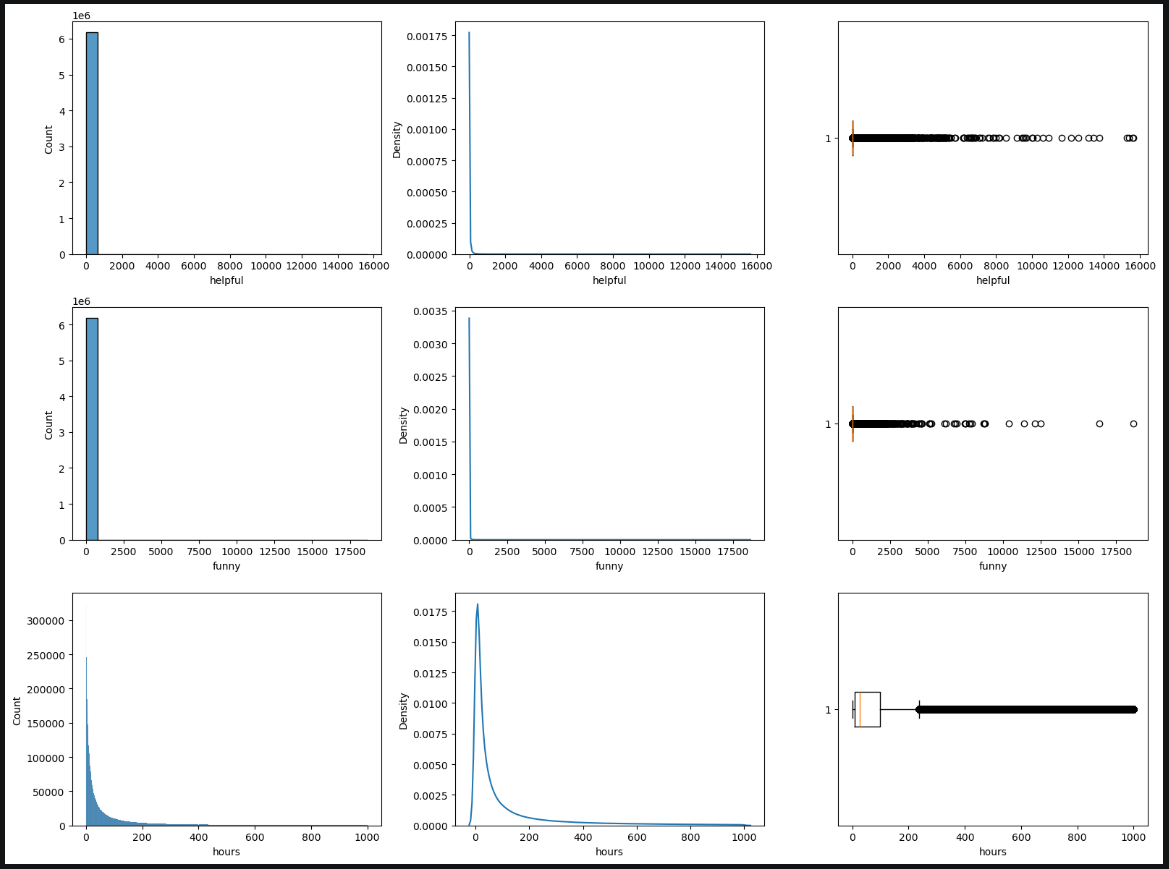

In [18]:
# The observation is that all three are extremely right-skewed. Hence, performing log transformations on all of them.
# Outliers are also present, but will be dealt with after this.
import numpy as np

interactions['hours_transformed'] = np.log1p(interactions['hours'])

In [19]:
interactions['helpful_transformed'] = np.log1p(interactions['helpful'])

In [20]:
interactions['funny_transformed'] = np.log1p(interactions['funny'])

In [21]:
interactions.drop(columns=['helpful', 'funny', 'hours'], inplace=True)
interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,hours_transformed,helpful_transformed,funny_transformed
0,431960,1,5029913,2022,3,7,4.919981,0.000000,0.000000
1,275850,1,7170282,2018,11,26,4.155753,1.098612,0.000000
2,1938090,0,13073598,2022,12,19,3.139833,0.000000,0.000000
3,526870,1,13002277,2020,6,14,3.342862,0.000000,0.000000
4,252490,0,4130104,2019,7,3,1.916923,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,3.465736,0.000000,0.000000
6173215,729040,1,5569834,2019,11,27,2.197225,0.000000,1.098612
6173216,633230,1,13056692,2021,11,26,4.442651,0.000000,0.000000
6173217,578330,1,3668243,2022,12,11,4.532599,0.000000,0.000000


In [22]:
# Saving the partially processed interactions set for v0 to avoid kernel crashes.
# Will load it again and proceed from there.
interactions.to_csv("~/projects/game_recommender_system/v0/data/processed/partially_processed_interactions.csv")

In [1]:
import pandas as pd

interactions = pd.read_csv("~/projects/game_recommender_system/v0/data/processed/partially_processed_interactions.csv", index_col='Unnamed: 0')
interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,hours_transformed,helpful_transformed,funny_transformed
0,431960,1,5029913,2022,3,7,4.919981,0.000000,0.000000
1,275850,1,7170282,2018,11,26,4.155753,1.098612,0.000000
2,1938090,0,13073598,2022,12,19,3.139833,0.000000,0.000000
3,526870,1,13002277,2020,6,14,3.342862,0.000000,0.000000
4,252490,0,4130104,2019,7,3,1.916923,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,3.465736,0.000000,0.000000
6173215,729040,1,5569834,2019,11,27,2.197225,0.000000,1.098612
6173216,633230,1,13056692,2021,11,26,4.442651,0.000000,0.000000
6173217,578330,1,3668243,2022,12,11,4.532599,0.000000,0.000000


In [2]:
# # Visualizing the numerical columns for understanding distributions to take corresponding actions, if any.
# import matplotlib.pyplot as plt
# import seaborn as sns

# num_cols = ['helpful_transformed', 'funny_transformed', 'hours_transformed']

# fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

# for i, col in enumerate(num_cols):
#     # histogram
#     sns.histplot(data=interactions, x=col, ax=ax[i, 0])
#     # kde plots
#     sns.kdeplot(interactions[col], ax=ax[i, 1]) # Because kernel keeps crashing, not now maybe?.
#     # box plots
#     ax[i, 2].boxplot(interactions[col], orientation='horizontal')
#     ax[i, 2].set_xlabel(f"{col}")

# plt.tight_layout()
# plt.show()

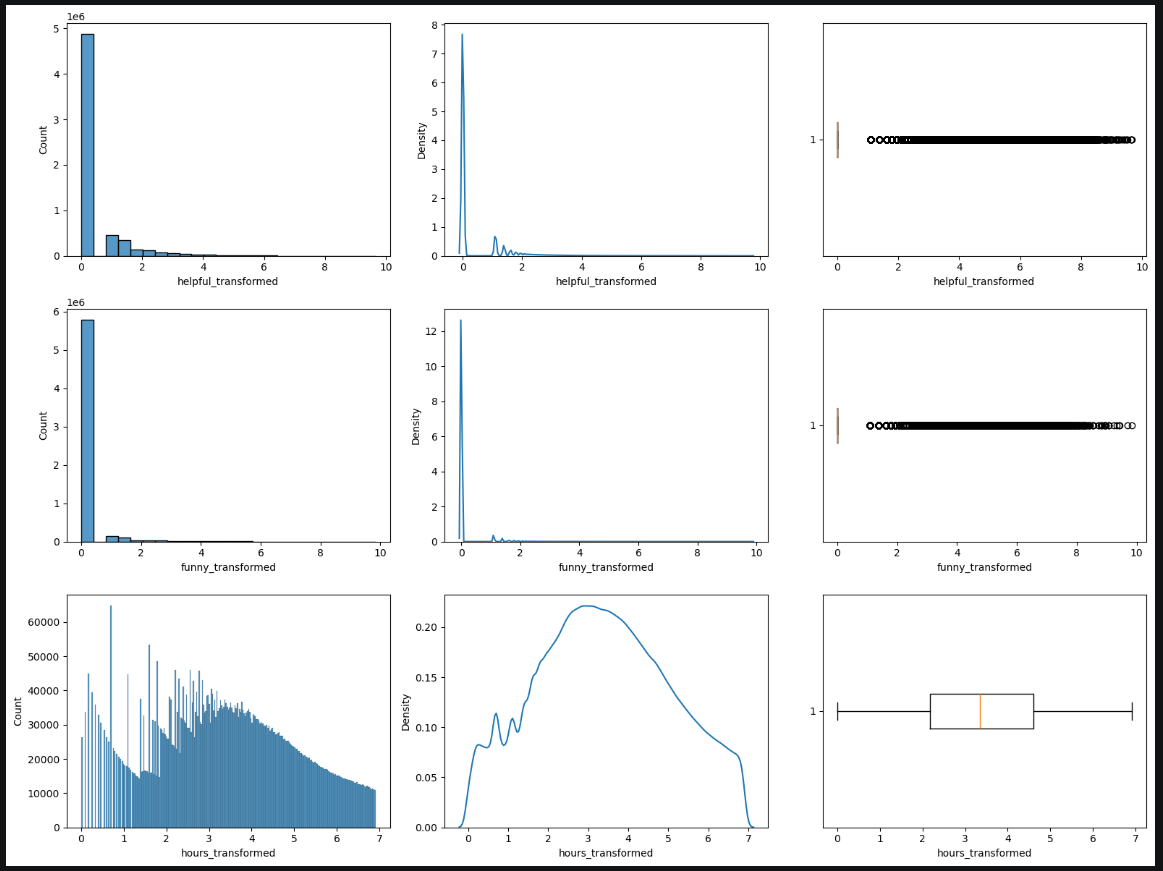

In [3]:
# The Observations are: {Colaaboration with GPT}
# helpful and funny are still heavily right-skewed with long tail. This suggests that they are sort of following a power-law distribution.
# This implies that these are enriched signals suggesting popular games, many reviews, etc. Supported by outliers as well, as mentioned earlier.
# Hence, preserve them with outlier treatment done. In addition, these are more of engagement or result-of-engagement signals with varying strengths.

In [4]:
# Clipping the outliers i.e., applying Winsorization {Syntax from GPT} | Removes extreme outlier influence as seen
upper = interactions['helpful_transformed'].quantile(0.99)
interactions['helpful_clipped'] = interactions['helpful_transformed'].clip(upper=upper)

upper = interactions['funny_transformed'].quantile(0.99)
interactions['funny_clipped'] = interactions['funny_transformed'].clip(upper=upper)

interactions.drop(columns=['helpful_transformed', 'funny_transformed'], inplace=True)
interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,hours_transformed,helpful_clipped,funny_clipped
0,431960,1,5029913,2022,3,7,4.919981,0.000000,0.000000
1,275850,1,7170282,2018,11,26,4.155753,1.098612,0.000000
2,1938090,0,13073598,2022,12,19,3.139833,0.000000,0.000000
3,526870,1,13002277,2020,6,14,3.342862,0.000000,0.000000
4,252490,0,4130104,2019,7,3,1.916923,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,3.465736,0.000000,0.000000
6173215,729040,1,5569834,2019,11,27,2.197225,0.000000,1.098612
6173216,633230,1,13056692,2021,11,26,4.442651,0.000000,0.000000
6173217,578330,1,3668243,2022,12,11,4.532599,0.000000,0.000000


In [6]:
# Normalization using Min-Max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ['hours_transformed', 'helpful_clipped', 'funny_clipped']
interactions[cols] = scaler.fit_transform(interactions[cols])
interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,hours_transformed,helpful_clipped,funny_clipped
0,431960,1,5029913,2022,3,7,0.712137,0.00000,0.00000
1,275850,1,7170282,2018,11,26,0.601520,0.28083,0.00000
2,1938090,0,13073598,2022,12,19,0.454472,0.00000,0.00000
3,526870,1,13002277,2020,6,14,0.483859,0.00000,0.00000
4,252490,0,4130104,2019,7,3,0.277463,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,0.501644,0.00000,0.00000
6173215,729040,1,5569834,2019,11,27,0.318035,0.00000,0.41629
6173216,633230,1,13056692,2021,11,26,0.643047,0.00000,0.00000
6173217,578330,1,3668243,2022,12,11,0.656066,0.00000,0.00000


In [7]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173219 entries, 0 to 6173218
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   app_id             int64  
 1   is_recommended     int64  
 2   user_id            int64  
 3   publish_year       int64  
 4   publish_month      int64  
 5   publish_day        int64  
 6   hours_transformed  float64
 7   helpful_clipped    float64
 8   funny_clipped      float64
dtypes: float64(3), int64(6)
memory usage: 471.0 MB


In [8]:
interactions = interactions.apply(pd.to_numeric, downcast='float')
interactions = interactions.apply(pd.to_numeric, downcast='integer')
interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,hours_transformed,helpful_clipped,funny_clipped
0,431960,1,5029913,2022,3,7,0.712137,0.00000,0.00000
1,275850,1,7170282,2018,11,26,0.601520,0.28083,0.00000
2,1938090,0,13073598,2022,12,19,0.454472,0.00000,0.00000
3,526870,1,13002277,2020,6,14,0.483859,0.00000,0.00000
4,252490,0,4130104,2019,7,3,0.277463,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,0.501644,0.00000,0.00000
6173215,729040,1,5569834,2019,11,27,0.318035,0.00000,0.41629
6173216,633230,1,13056692,2021,11,26,0.643047,0.00000,0.00000
6173217,578330,1,3668243,2022,12,11,0.656066,0.00000,0.00000


In [9]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173219 entries, 0 to 6173218
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   app_id             int32  
 1   is_recommended     int8   
 2   user_id            int32  
 3   publish_year       int16  
 4   publish_month      int8   
 5   publish_day        int8   
 6   hours_transformed  float32
 7   helpful_clipped    float32
 8   funny_clipped      float32
dtypes: float32(3), int16(1), int32(2), int8(3)
memory usage: 194.3 MB


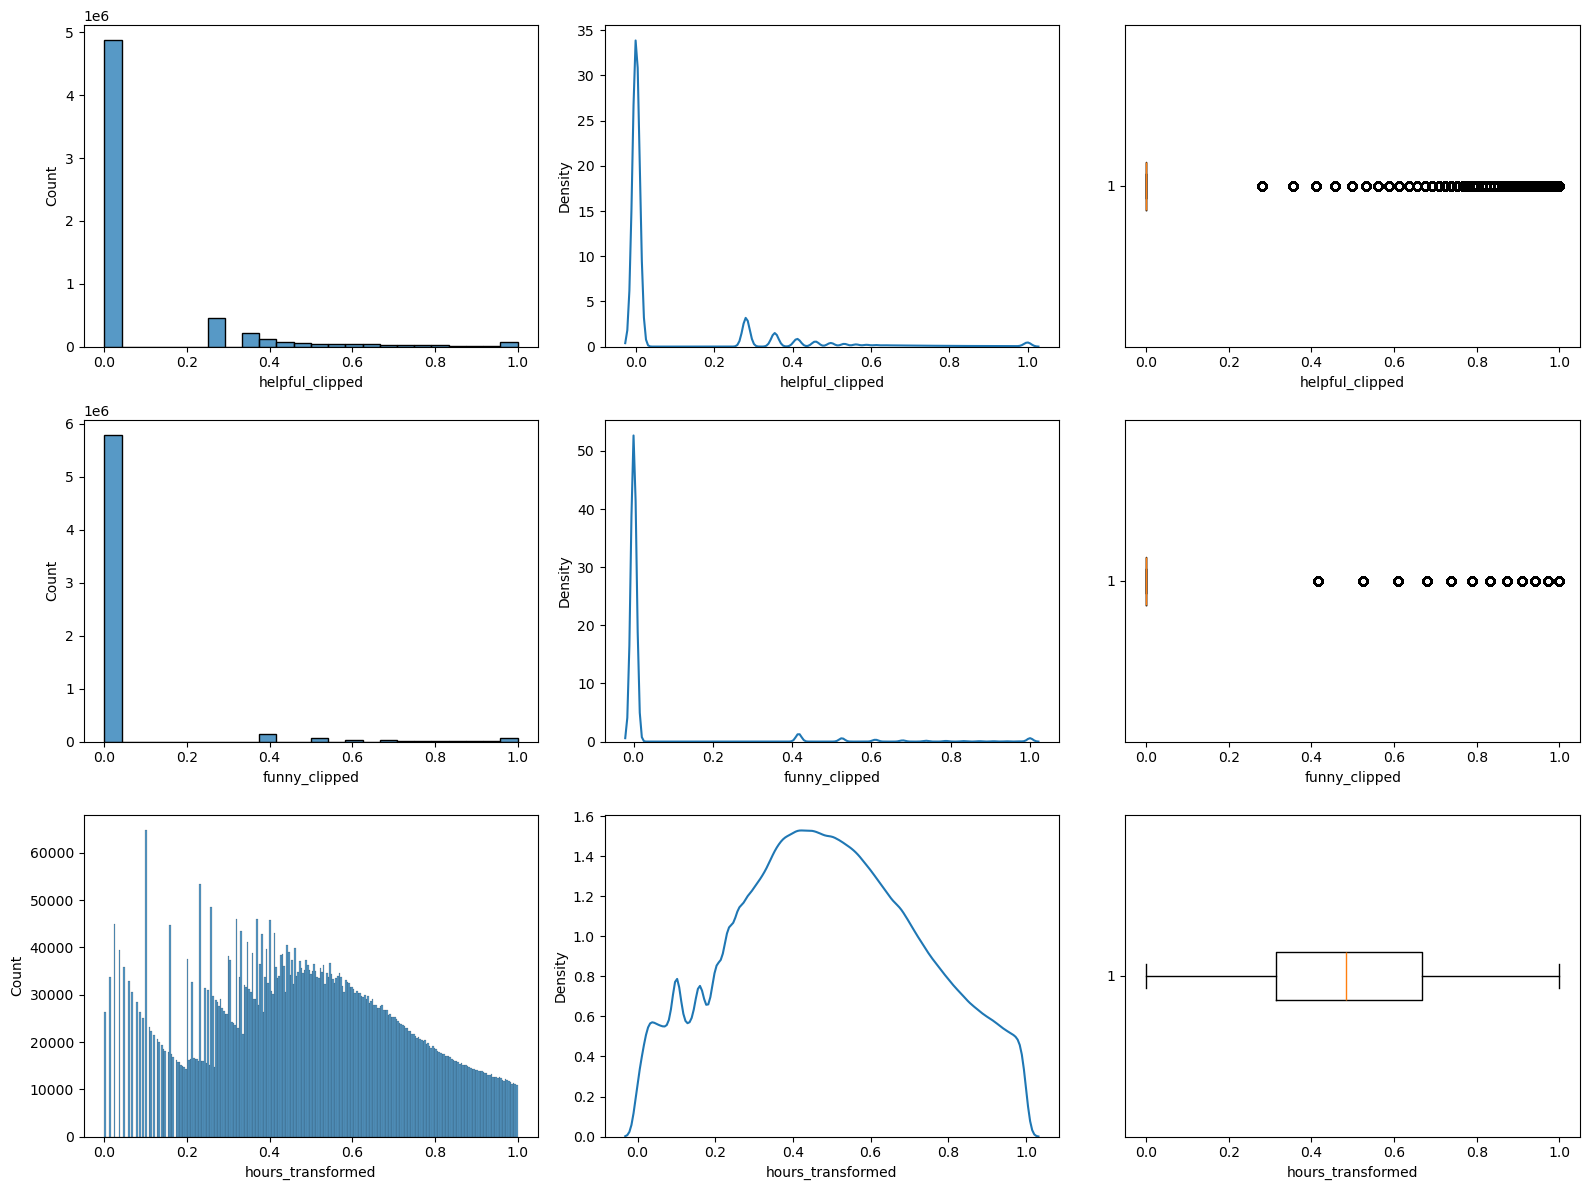

In [11]:
# Visualizing the numerical columns for understanding distributions to take corresponding actions, if any.
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['helpful_clipped', 'funny_clipped', 'hours_transformed']

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

for i, col in enumerate(num_cols):
    # histogram
    sns.histplot(data=interactions, x=col, ax=ax[i, 0])
    # kde plots
    sns.kdeplot(interactions[col], ax=ax[i, 1]) # Because kernel keeps crashing, not now maybe?.
    # box plots
    ax[i, 2].boxplot(interactions[col], orientation='horizontal')
    ax[i, 2].set_xlabel(f"{col}")

plt.tight_layout()
plt.show()

In [12]:
# This shows that hours is a continuous engagement signal and the other two are kind of feedback signals wrt their interaction/behavioural-use liking of the games. Hence, can be considered as implicit feedback.
# Moreover, a single score can be created as an implicit rating of that user for a game by combining all three in a weighted sum.
# This is done as follows:
interactions['implicit_rating'] = 0.7 * interactions['hours_transformed'] + 0.2 * interactions['helpful_clipped'] + 0.1 * interactions['funny_clipped']
interactions.drop(columns=['hours_transformed', 'helpful_clipped', 'funny_clipped'], inplace=True)
print(interactions.info())
interactions

<class 'pandas.core.frame.DataFrame'>
Index: 6173219 entries, 0 to 6173218
Data columns (total 7 columns):
 #   Column           Dtype  
---  ------           -----  
 0   app_id           int32  
 1   is_recommended   int8   
 2   user_id          int32  
 3   publish_year     int16  
 4   publish_month    int8   
 5   publish_day      int8   
 6   implicit_rating  float64
dtypes: float64(1), int16(1), int32(2), int8(3)
memory usage: 170.7 MB
None


,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
0,431960,1,5029913,2022,3,7,0.498496
1,275850,1,7170282,2018,11,26,0.477230
2,1938090,0,13073598,2022,12,19,0.318130
3,526870,1,13002277,2020,6,14,0.338701
4,252490,0,4130104,2019,7,3,0.194224
...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,0.351151
6173215,729040,1,5569834,2019,11,27,0.264253
6173216,633230,1,13056692,2021,11,26,0.450133
6173217,578330,1,3668243,2022,12,11,0.459246


In [13]:
# Done with the interactions' sampled dataseet to be used for user simulation. Hence, saving it.
interactions.to_csv("~/projects/game_recommender_system/v0/data/processed/processed_sampled_interactions_v0.csv")

In [14]:
# Onto user simulation to have real users for both building user profiles and henceforth test the provided recommendations based them itseld.

In [1]:
# Loading interactions data of users
import pandas as pd

user_interactions = pd.read_csv("~/projects/game_recommender_system/v0/data/processed/processed_sampled_interactions_v0.csv", index_col='Unnamed: 0')
user_interactions

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
0,431960,1,5029913,2022,3,7,0.498496
1,275850,1,7170282,2018,11,26,0.477230
2,1938090,0,13073598,2022,12,19,0.318130
3,526870,1,13002277,2020,6,14,0.338701
4,252490,0,4130104,2019,7,3,0.194224
...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,0.351151
6173215,729040,1,5569834,2019,11,27,0.264253
6173216,633230,1,13056692,2021,11,26,0.450133
6173217,578330,1,3668243,2022,12,11,0.459246


In [2]:
# check how many unique users are there? To use and simulate a certain numbers of users of v0 system.
print(user_interactions.user_id.unique().size)

unique_user_ids = user_interactions.user_id.unique()
unique_users = user_interactions[user_interactions.user_id.isin(unique_user_ids)]
unique_users

3993287


,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
0,431960,1,5029913,2022,3,7,0.498496
1,275850,1,7170282,2018,11,26,0.477230
2,1938090,0,13073598,2022,12,19,0.318130
3,526870,1,13002277,2020,6,14,0.338701
4,252490,0,4130104,2019,7,3,0.194224
...,...,...,...,...,...,...,...
6173214,1057090,1,1235278,2022,12,29,0.351151
6173215,729040,1,5569834,2019,11,27,0.264253
6173216,633230,1,13056692,2021,11,26,0.450133
6173217,578330,1,3668243,2022,12,11,0.459246


In [3]:
# This implies that the original dataset is the unique_users dataset. Quite obvious. {Concluded after discussion with GPT}
del unique_user_ids
del unique_users

In [4]:
# now, see the number of interactions per user?
user_groups = user_interactions.groupby('user_id', as_index=False, sort=False)
user_group_sizes = user_groups.size().sort_values(by='size', ascending=False)
user_group_sizes

,user_id,size
464127,11764552,926
1203671,5112758,621
410796,11656130,562
1421294,5669734,552
172279,11553593,506
...,...,...
3993271,6338127,1
3993270,1083672,1
3993269,12114596,1
3993268,11122425,1


In [5]:
# verify the group sizes
user_interactions[user_interactions.user_id == 11764552]

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
490846,239030,0,11764552,2020,6,6,0.269436
873149,376210,0,11764552,2018,8,21,0.123364
982162,1258080,0,11764552,2021,4,17,0.080530
1080456,784950,0,11764552,2022,7,8,0.080530
1113590,1343370,0,11764552,2021,3,25,0.107452
...,...,...,...,...,...,...,...
6094390,712730,0,11764552,2021,4,10,0.000000
6097688,1296510,0,11764552,2022,1,19,0.123403
6100662,244710,0,11764552,2020,5,10,0.126396
6103964,310790,0,11764552,2019,11,13,0.000000


In [6]:
# Need to set a threshold for minimum number of interactions in each group per user
user_group_sizes['size'].value_counts().sort_index()[:35]

size
1     3011549
2      572827
3      192529
4       85551
5       44215
6       25746
7       16008
8       10507
9        7583
10       5448
11       3915
12       3124
13       2291
14       1837
15       1455
16       1166
17        962
18        721
19        680
20        557
21        459
22        397
23        358
24        308
25        275
26        224
27        217
28        184
29        164
30        176
31        129
32        111
33        109
34         89
35         77
Name: count, dtype: int64

In [7]:
# Observing and inferencing the above output list, threshould is decided to be 20 for user to be considered active.
# Hence, filtering them out now.
active_user_ids = user_group_sizes[user_group_sizes['size'] >= 20]['user_id']
user_group_sizes[user_group_sizes.user_id.isin(active_user_ids)]

,user_id,size
464127,11764552,926
1203671,5112758,621
410796,11656130,562
1421294,5669734,552
172279,11553593,506
...,...,...
1427510,11689633,20
1311255,4426499,20
984210,3008288,20
950865,10462679,20


In [8]:
user_group_sizes[user_group_sizes.user_id.isin(active_user_ids)]['size'].sum()

np.int64(183048)

In [9]:
del user_group_sizes, user_groups

In [10]:
# Filtering out the active user ids' rows
user_groups_simulated_df = user_interactions[user_interactions.user_id.isin(active_user_ids)].copy()
user_groups_simulated_df.sort_values(by=['publish_year', 'publish_month', 'publish_day'], inplace=True)
user_groups_simulated_df.reset_index(drop=True)

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
0,6910,1,6808967,2010,10,15,0.387698
1,32370,1,7378551,2010,10,16,0.532890
2,21010,0,11849813,2010,10,16,0.289634
3,41500,1,6237903,2010,10,18,0.453647
4,8400,1,6237903,2010,10,18,0.059555
...,...,...,...,...,...,...,...
183043,2100050,1,11760344,2022,12,31,0.179839
183044,1179060,0,6732547,2022,12,31,0.226866
183045,1109160,1,8918391,2022,12,31,0.169714
183046,615610,0,12188152,2022,12,31,0.211334


In [11]:
# Creating the groups of filtered active users
simulated_users = user_groups_simulated_df.groupby('user_id')
simulated_users

In [12]:
print(simulated_users.size())
simulated_users.size().sum()

user_id
1239        50
2821        69
2881        25
3629        21
8142        24
            ..
14283059    42
14283841    30
14284627    24
14287597    24
14300514    24
Length: 5173, dtype: int64


np.int64(183048)

In [13]:
simulated_users.get_group(1239)

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
4995773,982580,1,1239,2019,9,12,0.100755
5693974,463150,1,1239,2019,9,25,0.161022
4246731,1054930,1,1239,2019,9,26,0.223096
1561898,49520,1,1239,2019,10,2,0.643341
4702637,280160,1,1239,2019,10,24,0.361148
4230618,304460,1,1239,2019,11,2,0.359321
5590652,38740,1,1239,2019,11,4,0.171343
4818595,422970,1,1239,2019,12,10,0.186206
5646974,1156000,1,1239,2019,12,12,0.284398
5342504,909080,1,1239,2020,1,16,0.374116


In [29]:
print(simulated_users.get_group(1239).shape)
type(simulated_users.get_group(1239))

(50, 7)


pandas.core.frame.DataFrame

In [15]:
# saving the grouped by simulated users in csv file.
simulated_users_df = simulated_users.obj
simulated_users_df.reset_index(drop=True)
simulated_users_df.to_csv("~/projects/game_recommender_system/v0/data/processed/simulated_users_v0.csv", index=False)

In [16]:
# for verification purposes beefore doing user-based temporal data splitting
simu_users = pd.read_csv("~/projects/game_recommender_system/v0/data/processed/simulated_users_v0.csv")
simu_users

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
0,6910,1,6808967,2010,10,15,0.387698
1,32370,1,7378551,2010,10,16,0.532890
2,21010,0,11849813,2010,10,16,0.289634
3,41500,1,6237903,2010,10,18,0.453647
4,8400,1,6237903,2010,10,18,0.059555
...,...,...,...,...,...,...,...
183043,2100050,1,11760344,2022,12,31,0.179839
183044,1179060,0,6732547,2022,12,31,0.226866
183045,1109160,1,8918391,2022,12,31,0.169714
183046,615610,0,12188152,2022,12,31,0.211334


In [20]:
# Onto train-test split temporally per user for user profile creation and testing the provided recommendations
from tqdm.auto import tqdm

train = []
test = []

for user_id, group in tqdm(simulated_users, desc='User groups split...'):
    # To ensure time is correct
    group = group.sort_values(by=['publish_year', 'publish_month', 'publish_day'])
    split_idx = int(len(group) * 0.7)
    train.append(group.iloc[:split_idx])
    test.append(group.iloc[split_idx:])

train_simu_users = pd.concat(train)
test_simu_users = pd.concat(test)

User groups split...: 100%|██████████| 5173/5173 [00:04<00:00, 1177.41it/s]


In [32]:
train_simu_users

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
4995773,982580,1,1239,2019,9,12,0.100755
5693974,463150,1,1239,2019,9,25,0.161022
4246731,1054930,1,1239,2019,9,26,0.223096
1561898,49520,1,1239,2019,10,2,0.643341
4702637,280160,1,1239,2019,10,24,0.361148
...,...,...,...,...,...,...,...
2587833,375910,1,14300514,2021,3,29,0.420750
1845887,1167630,1,14300514,2021,4,11,0.224851
2150636,433550,1,14300514,2021,4,11,0.215099
1838438,1157220,1,14300514,2021,4,13,0.365084


In [34]:
test_simu_users

,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
5565477,1698960,1,1239,2021,10,26,0.251179
5969495,720280,1,1239,2021,10,31,0.325546
4413070,250180,1,1239,2021,11,2,0.308791
6086930,1049100,1,1239,2021,11,3,0.397161
5547142,1060180,1,1239,2021,11,8,0.169012
...,...,...,...,...,...,...,...
4367251,230230,1,14300514,2021,6,29,0.286433
370225,518790,1,14300514,2021,7,31,0.408296
4590214,917720,0,14300514,2021,11,11,0.509910
476034,1245620,1,14300514,2022,8,1,0.492667


In [33]:
print(train_simu_users[train_simu_users.user_id == 1239].shape)
train_simu_users[train_simu_users.user_id == 1239]

(35, 7)


,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
4995773,982580,1,1239,2019,9,12,0.100755
5693974,463150,1,1239,2019,9,25,0.161022
4246731,1054930,1,1239,2019,9,26,0.223096
1561898,49520,1,1239,2019,10,2,0.643341
4702637,280160,1,1239,2019,10,24,0.361148
4230618,304460,1,1239,2019,11,2,0.359321
5590652,38740,1,1239,2019,11,4,0.171343
4818595,422970,1,1239,2019,12,10,0.186206
5646974,1156000,1,1239,2019,12,12,0.284398
5342504,909080,1,1239,2020,1,16,0.374116


In [35]:
print(test_simu_users[test_simu_users.user_id == 1239].shape)
test_simu_users[test_simu_users.user_id == 1239]

(15, 7)


,app_id,is_recommended,user_id,publish_year,publish_month,publish_day,implicit_rating
5565477,1698960,1,1239,2021,10,26,0.251179
5969495,720280,1,1239,2021,10,31,0.325546
4413070,250180,1,1239,2021,11,2,0.308791
6086930,1049100,1,1239,2021,11,3,0.397161
5547142,1060180,1,1239,2021,11,8,0.169012
5572625,317840,1,1239,2021,11,21,0.198003
4189870,1377450,1,1239,2022,1,24,0.294853
5697374,1600900,1,1239,2022,1,29,0.259289
4953568,976390,1,1239,2022,2,3,0.427095
4799738,206440,1,1239,2022,2,12,0.360813


In [38]:
# Done with user simulation and its respective splits. Saving them now.
train_simu_users.to_csv("~/projects/game_recommender_system/v0/data/processed/train_user_simulations_v0.csv", index=False)
test_simu_users.to_csv("~/projects/game_recommender_system/v0/data/processed/test_user_simulations_v0.csv", index=False)